In [2]:
import pandas as pd
df = pd.read_csv(r"wandb_logs\wandb_hyper_nas_full.csv")
df.head()

,Name,State,Created,freeze_layers,eval/accuracy,batch_size,normalisation,activation_fn,dropout_top,learning_rate,seed,test_accuracvy,test_accuracy
0,trial_21,finished,2025-07-31T11:40:37.000Z,0,0.669903,4,none,none,0.335753,0.000048,42,NaN,NaN
1,trial_20,finished,2025-07-31T11:27:22.000Z,5,0.635922,4,none,none,0.348681,0.000013,42,NaN,NaN
2,trial_19,finished,2025-07-31T11:13:53.000Z,0,0.614078,4,none,none,0.391120,0.000788,42,NaN,NaN
3,trial_18,finished,2025-07-31T11:00:24.000Z,0,0.635922,4,layer,relu,0.241718,0.000471,42,NaN,NaN
4,trial_17,finished,2025-07-31T10:47:03.000Z,3,0.650485,4,none,relu,0.351756,0.000161,42,NaN,NaN


In [3]:
len(df)

22

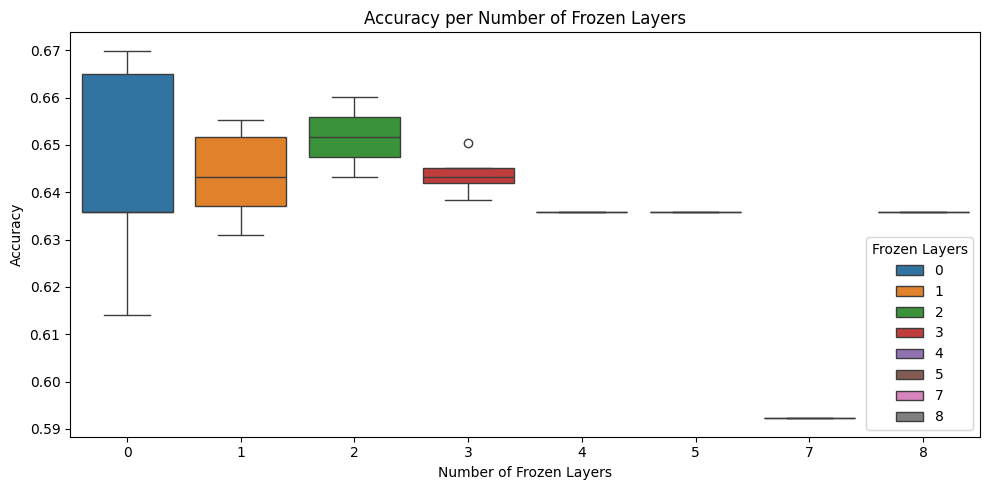

In [4]:
import seaborn as sns  # with 11
import matplotlib.pyplot as plt
#df['hyperparams.freeze_layers'] = df['hyperparams.freeze_layers'].astype(str)  # or use Categorical if you want specific order

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='freeze_layers', y='eval/accuracy', hue='freeze_layers',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_4216\3648468556.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Frozen Layers")


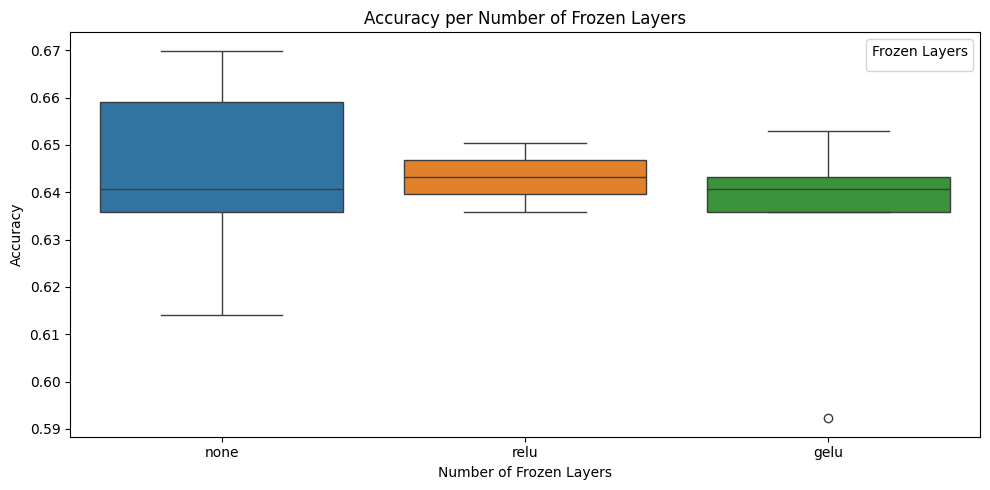

In [5]:
import seaborn as sns  # with 11
import matplotlib.pyplot as plt
#df['hyperparams.freeze_layers'] = df['hyperparams.freeze_layers'].astype(str)  # or use Categorical if you want specific order

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='activation_fn', y='eval/accuracy', hue='activation_fn',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_4216\1354904755.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Frozen Layers")


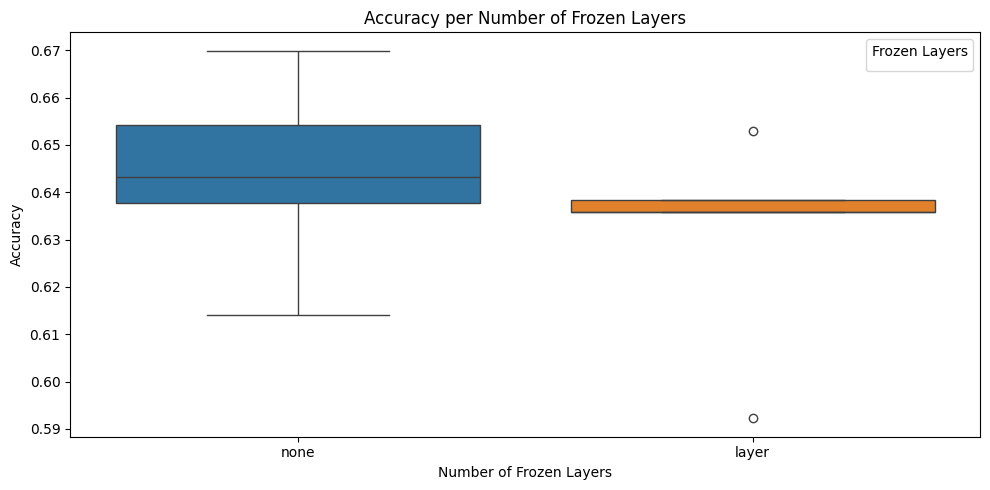

In [6]:
import seaborn as sns  # with 11
import matplotlib.pyplot as plt
#df['hyperparams.freeze_layers'] = df['hyperparams.freeze_layers'].astype(str)  # or use Categorical if you want specific order

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='normalisation', y='eval/accuracy', hue='normalisation',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

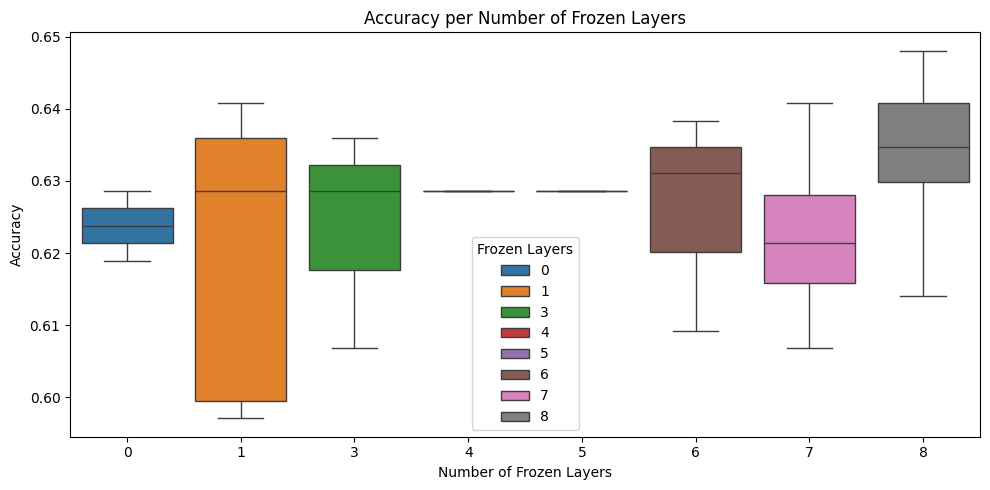

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
#df['hyperparams.freeze_layers'] = df['hyperparams.freeze_layers'].astype(str)  # or use Categorical if you want specific order

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='freeze_layers', y='eval/accuracy', hue='freeze_layers',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\744773637.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Frozen Layers")


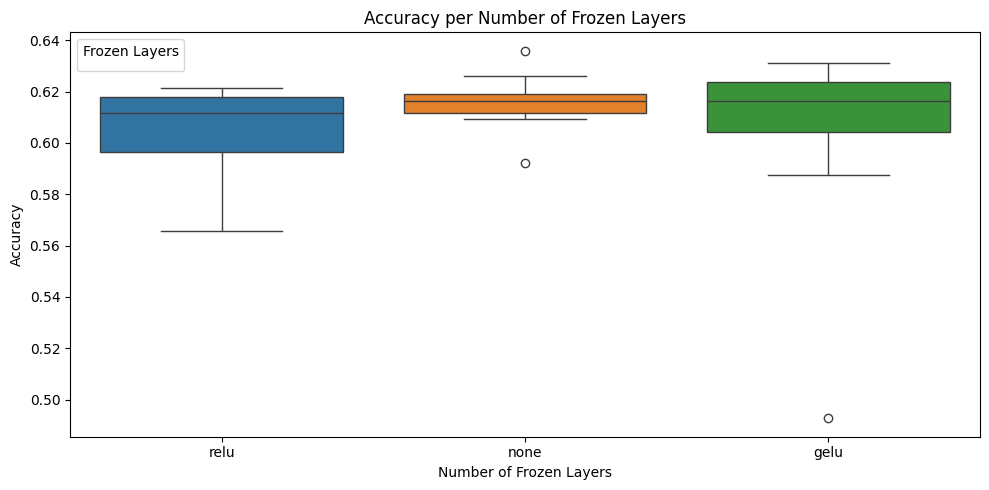

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='activation_fn', y='eval/accuracy', hue='activation_fn',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\3007680202.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])


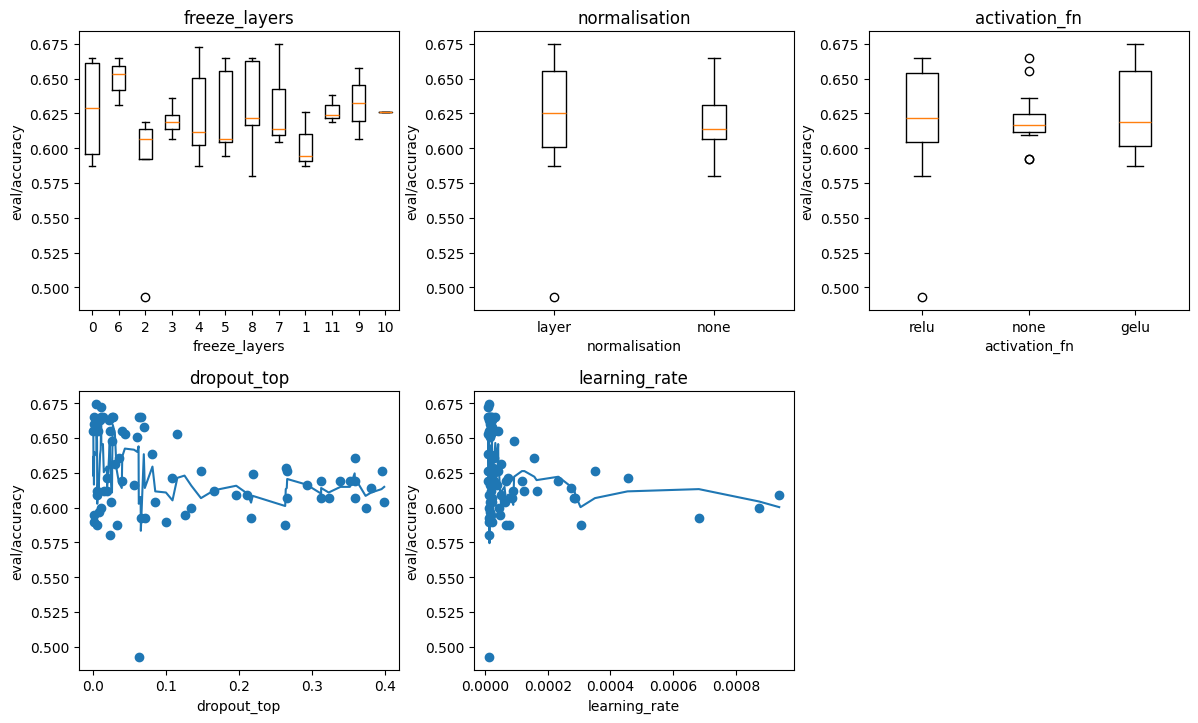

In [89]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# df should have: ["freeze_layers","normalisation","activation_fn","dropout_top",
#                  "learning_rate","accuracy"]
df['freeze_layers'] = df['freeze_layers'].astype(str) 
params = ["freeze_layers","normalisation","activation_fn","dropout_top","learning_rate"]
n = len(params)
rows = cols = math.ceil(math.sqrt(n))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows))
axes = axes.flatten()

def plot_param(ax, df, col):
    y = "eval/accuracy"
    if pd.api.types.is_numeric_dtype(df[col]):
        ax.scatter(df[col], df[y])
        # optional: running mean to see trend
        df_sorted = df.sort_values(col)
        rolling = df_sorted[y].rolling(window=max(1,len(df)//20), min_periods=1).mean()
        ax.plot(df_sorted[col], rolling)
        ax.set_xlabel(col)
        ax.set_ylabel(y)
    else:
        # categorical: show boxplots (or strip)
        groups = [g[y].values for _, g in df.groupby(col)]
        ax.boxplot(groups, labels=[str(k) for k in df[col].unique()])
        ax.set_xlabel(col)
        ax.set_ylabel(y)
    ax.set_title(col)

for i, p in enumerate(params):
    plot_param(axes[i], df, p)

# remove empty axes (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()


In [85]:
import pandas as pd
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

y = df["eval/accuracy"].values
num = ["learning_rate", "dropout_top", "freeze_layers"]  # if numeric
cat = ["normalisation", "activation_fn"]

# Spearman
spearman = {c: stats.spearmanr(df[c], y, nan_policy="omit").correlation for c in num}

# Mutual information (handles non-linear)
mi = mutual_info_regression(df[num], y, random_state=0)
mi = dict(zip(num, mi))

# ANOVA eta-squared for categorical
def eta_squared(cat_col):
    groups = [g["eval/accuracy"].values for _, g in df.groupby(cat_col)]
    f, p = stats.f_oneway(*groups)
    ss_between = sum(len(g)*((g.mean()-y.mean())**2) for g in groups)
    ss_total = ((y - y.mean())**2).sum()
    return ss_between/ss_total
etas = {c: eta_squared(c) for c in cat}


In [86]:
etas

{'normalisation': 0.008298971849900772, 'activation_fn': 0.011874822747584867}

In [87]:
spearman

{'learning_rate': -0.305501203740946,
 'dropout_top': -0.2608150009628594,
 'freeze_layers': -0.130142524913086}

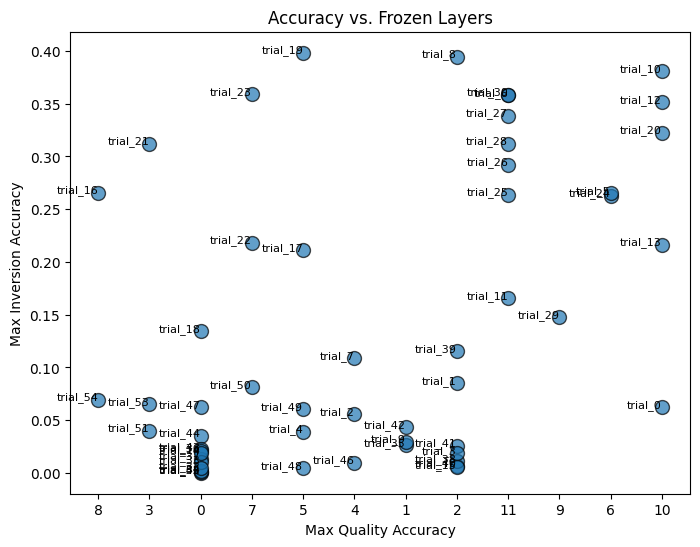

In [75]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["freeze_layers"],
    df["dropout_top"],
    s=100,  # bigger size for fewer frozen layers
    alpha=0.7,
    edgecolor='k'
)

plt.xlabel('Max Quality Accuracy')
plt.ylabel('Max Inversion Accuracy')
plt.title('Accuracy vs. Frozen Layers')

# Optional: add trial names
for i, row in df.iterrows():
    plt.text(
        row["freeze_layers"],
        row["dropout_top"],
        row['Name'],
        fontsize=8,
        ha='right'
    )

#plt.grid(True)
plt.show()

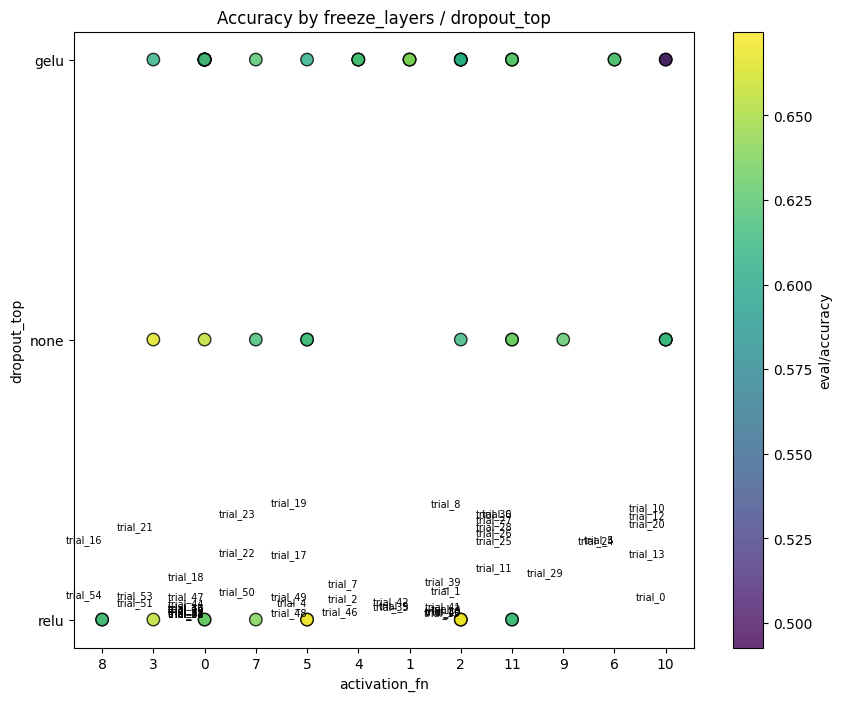

In [81]:
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    df["freeze_layers"],
    df["activation_fn"],
    s=80,                               # constant size
    c=df["eval/accuracy"],              # color = accuracy
    cmap="viridis",
    alpha=0.8,
    edgecolors="k"
)

ax.set_xlabel("activation_fn")
ax.set_ylabel("dropout_top")
ax.set_title("Accuracy by freeze_layers / dropout_top")
fig.colorbar(sc, ax=ax, label="eval/accuracy")

for _, row in df.iterrows():
    ax.text(row["freeze_layers"], row["dropout_top"], row["Name"],
            fontsize=7, ha="right", va="bottom")

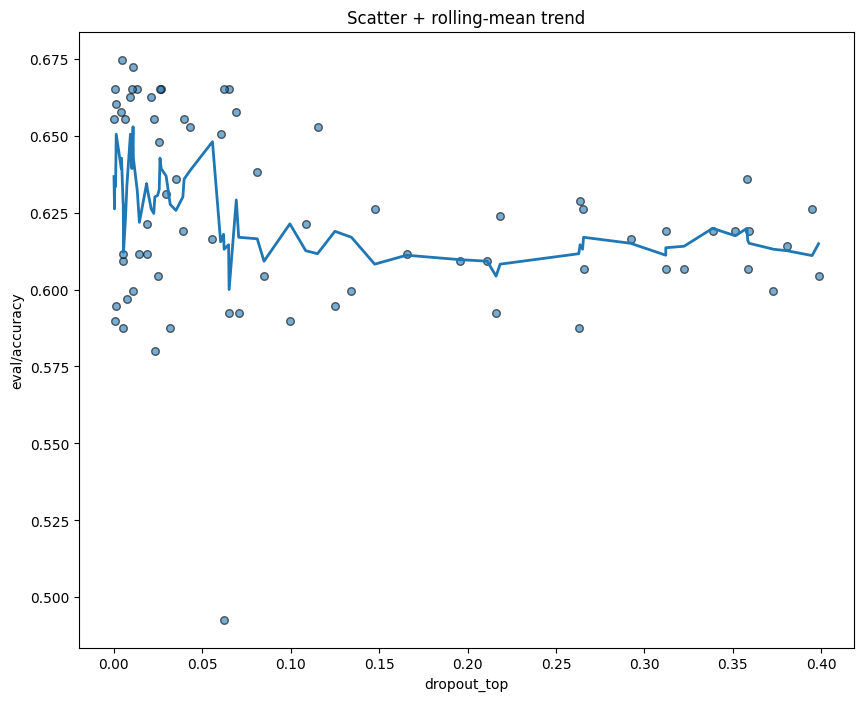

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume df has columns "dropout_top" and "eval/accuracy"
x = df["dropout_top"].values
y = df["eval/accuracy"].values

fig, ax = plt.subplots(figsize=(10, 8))

# 1a) raw scatter
ax.scatter(x, y, alpha=0.6, edgecolors="k", s=30)

# 1b) smoothed trend via rolling mean
order = np.argsort(x)
x_sorted = x[order]
y_sorted = y[order]
window = max(5, len(x)//20)  # e.g. 5‑point window or 5% of data
y_smooth = pd.Series(y_sorted).rolling(window, min_periods=1, center=True).mean()

ax.plot(x_sorted, y_smooth, lw=2)

ax.set_xlabel("dropout_top")
ax.set_ylabel("eval/accuracy")
ax.set_title("Scatter + rolling‑mean trend")
plt.show()


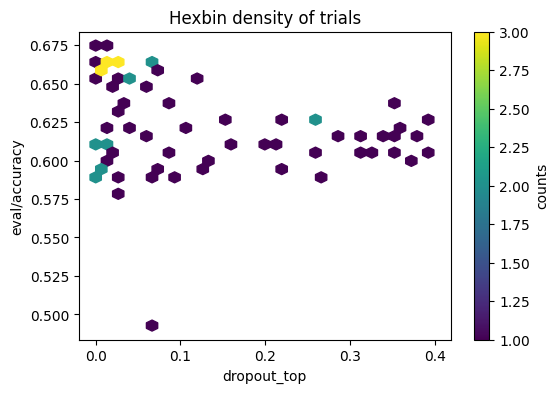

In [93]:
fig, ax = plt.subplots(figsize=(6, 4))
hb = ax.hexbin(x, y, gridsize=30, mincnt=1, cmap="viridis")
fig.colorbar(hb, ax=ax, label="counts")

ax.set_xlabel("dropout_top")
ax.set_ylabel("eval/accuracy")
ax.set_title("Hexbin density of trials")
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\1389619589.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["eval/accuracy"].values for _, g in df.groupby("drop_bin")]
C:\Users\Marina\AppData\Local\Temp\ipykernel_17284\1389619589.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[f"{i:.2f}–{j:.2f}"


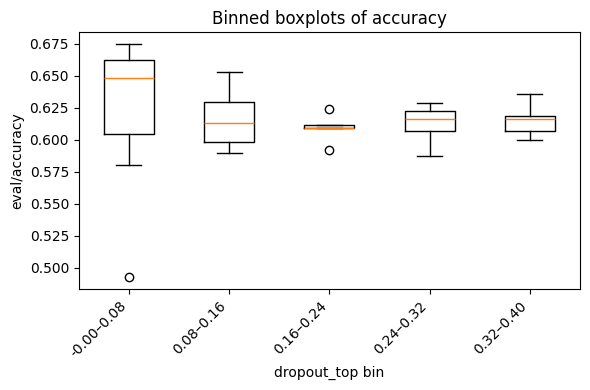

In [94]:
# Create 5 equal‑width bins
df["drop_bin"] = pd.cut(df["dropout_top"], bins=5)

fig, ax = plt.subplots(figsize=(6, 4))
groups = [g["eval/accuracy"].values for _, g in df.groupby("drop_bin")]

ax.boxplot(groups, labels=[f"{i:.2f}–{j:.2f}" 
                           for i,j in zip(df["drop_bin"].cat.categories.left,
                                          df["drop_bin"].cat.categories.right)])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("dropout_top bin")
ax.set_ylabel("eval/accuracy")
ax.set_title("Binned boxplots of accuracy")
plt.tight_layout()
plt.show()

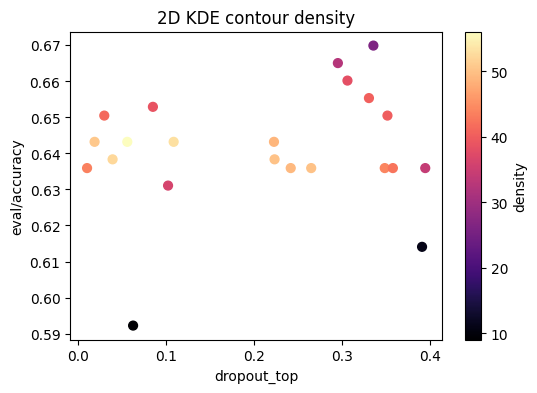

In [8]:
from scipy.stats import gaussian_kde

xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(x, y, c=z, s=40,  cmap="magma")
fig.colorbar(sc, ax=ax, label="density")

ax.set_xlabel("dropout_top")
ax.set_ylabel("eval/accuracy")
ax.set_title("2D KDE contour density")
plt.show()

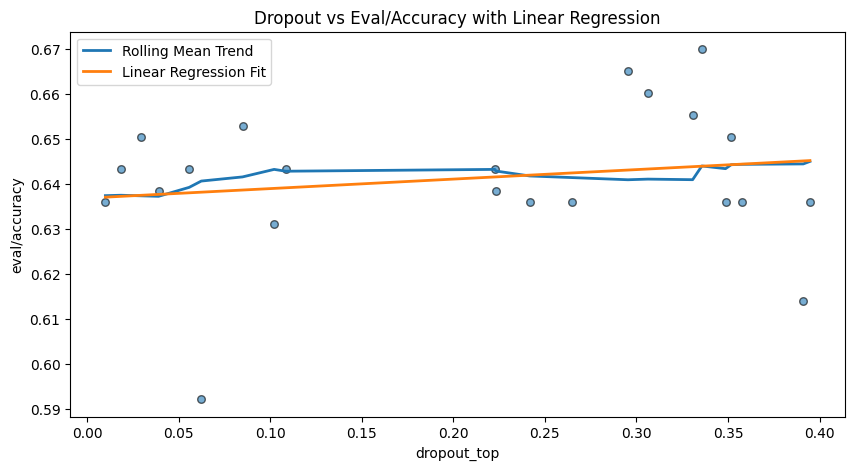

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Assume df is already loaded with columns "dropout_top" and "eval/accuracy"
x = df["dropout_top"].values
y = df["eval/accuracy"].values

# Fit linear regression
X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)
coef = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

# Prepare data for plotting
order = np.argsort(x)
x_sorted = x[order]
y_pred_sorted = model.predict(x_sorted.reshape(-1, 1))

# Compute rolling mean for trend line
window = max(8, len(x) // 20)
y_smooth = pd.Series(y[order]).rolling(window= 20, min_periods=4, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, alpha=0.6, edgecolors='k', s=30)
ax.plot(x_sorted, y_smooth, lw=2, label='Rolling Mean Trend')
ax.plot(x_sorted, y_pred_sorted, lw=2, label='Linear Regression Fit')

ax.set_xlabel("dropout_top")
ax.set_ylabel("eval/accuracy")
ax.set_title("Dropout vs Eval/Accuracy with Linear Regression")
ax.legend()

# Annotate equation and R^2
# ax.text(
#     0.05, 0.95,
#     f"y = {coef:.3f}x + {intercept:.3f}\n$R^2$ = {r2:.3f}",
#     transform=ax.transAxes,
#     va='top',
#     fontsize=12,
#     bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.7)
# )

plt.show()


In [108]:
import os
import optuna
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.patches import Patch
from optuna.importance import get_param_importances, FanovaImportanceEvaluator
pruner = optuna.pruners.MedianPruner(n_warmup_steps=0)
sampler = optuna.samplers.TPESampler(seed=42, 
                                         multivariate=True,
                                         warn_independent_sampling=False)
study = optuna.create_study(study_name="nas_full_11_freeze",
                                direction= "maximize",
                                sampler = sampler,
                                pruner = pruner,
                                storage = "sqlite:///ast_model//optuna.db",
                                load_if_exists=True )


c:\Users\Marina\genres\beat_venv_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Marina\genres\beat_venv_new\Lib\site-packages\optuna\_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(


OperationalError: (sqlite3.OperationalError) unable to open database file
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [109]:
df.head()

,Name,State,Created,freeze_layers,eval/accuracy,batch_size,normalisation,activation_fn,dropout_top,learning_rate,drop_bin
0,trial_72,finished,2025-07-23T23:46:12.000Z,0,0.597087,4,layer,relu,0.007397,0.000014,"(-0.000255, 0.0798]"
1,trial_71,finished,2025-07-23T23:38:12.000Z,0,0.592233,4,layer,none,0.065211,0.000011,"(-0.000255, 0.0798]"
2,trial_70,finished,2025-07-23T23:31:03.000Z,0,0.589806,4,layer,gelu,0.099567,0.000012,"(0.0798, 0.159]"
3,trial_69,finished,2025-07-23T23:23:51.000Z,0,0.589806,4,layer,gelu,0.000425,0.000022,"(-0.000255, 0.0798]"
4,trial_68,finished,2025-07-23T23:15:45.000Z,6,0.594660,4,layer,relu,0.001034,0.000049,"(-0.000255, 0.0798]"


In [122]:
df[["eval/accuracy"]].var()

eval/accuracy    0.000964
dtype: float64

In [123]:
df[["eval/accuracy"]].mean()

eval/accuracy    0.624064
dtype: float64

In [113]:
df.sort_values(by= "eval/accuracy", axis = 0, ascending=False).head(10)

,Name,State,Created,freeze_layers,eval/accuracy,batch_size,normalisation,activation_fn,dropout_top,learning_rate,drop_bin
23,trial_48,finished,2025-07-23T18:43:25.000Z,5,0.674757,4,layer,relu,0.004396,0.000011,"(-0.000255, 0.0798]"
33,trial_38,finished,2025-07-23T17:05:57.000Z,2,0.672330,4,layer,relu,0.010915,0.000010,"(-0.000255, 0.0798]"
18,trial_53,finished,2025-07-23T19:37:06.000Z,3,0.665049,4,layer,none,0.064907,0.000010,"(-0.000255, 0.0798]"
26,trial_45,finished,2025-07-23T18:21:38.000Z,0,0.665049,4,layer,gelu,0.000517,0.000021,"(-0.000255, 0.0798]"
16,trial_56,finished,2025-07-23T21:04:07.000Z,4,0.665049,4,layer,relu,0.026798,0.000014,"(-0.000255, 0.0798]"
38,trial_33,finished,2025-07-23T16:11:55.000Z,0,0.665049,4,none,gelu,0.010248,0.000032,"(-0.000255, 0.0798]"
36,trial_35,finished,2025-07-23T16:36:53.000Z,1,0.665049,4,layer,gelu,0.026146,0.000011,"(-0.000255, 0.0798]"
34,trial_37,finished,2025-07-23T16:58:42.000Z,0,0.665049,4,layer,gelu,0.013308,0.000019,"(-0.000255, 0.0798]"
24,trial_47,finished,2025-07-23T18:36:10.000Z,0,0.665049,4,layer,relu,0.062077,0.000011,"(-0.000255, 0.0798]"
25,trial_46,finished,2025-07-23T18:28:56.000Z,4,0.662621,4,layer,gelu,0.009414,0.000021,"(-0.000255, 0.0798]"


In [114]:
df.sort_values(by= "eval/accuracy", axis = 0, ascending=False).tail(10)

,Name,State,Created,freeze_layers,eval/accuracy,batch_size,normalisation,activation_fn,dropout_top,learning_rate,drop_bin
57,trial_13,finished,2025-07-23T12:17:44.000Z,10,0.592233,4,layer,none,0.216116,0.000682,"(0.159, 0.239]"
1,trial_71,finished,2025-07-23T23:38:12.000Z,0,0.592233,4,layer,none,0.065211,0.000011,"(-0.000255, 0.0798]"
7,trial_65,finished,2025-07-23T22:48:12.000Z,0,0.592233,4,layer,relu,0.070623,0.000016,"(-0.000255, 0.0798]"
3,trial_69,finished,2025-07-23T23:23:51.000Z,0,0.589806,4,layer,gelu,0.000425,0.000022,"(-0.000255, 0.0798]"
2,trial_70,finished,2025-07-23T23:31:03.000Z,0,0.589806,4,layer,gelu,0.099567,0.000012,"(0.0798, 0.159]"
46,trial_24,finished,2025-07-23T14:17:31.000Z,6,0.587379,4,layer,gelu,0.262858,0.000304,"(0.239, 0.319]"
8,trial_64,finished,2025-07-23T22:40:10.000Z,0,0.587379,4,layer,relu,0.031911,0.000076,"(-0.000255, 0.0798]"
5,trial_67,finished,2025-07-23T23:08:36.000Z,2,0.587379,4,none,gelu,0.005510,0.000065,"(-0.000255, 0.0798]"
12,trial_60,finished,2025-07-23T21:57:26.000Z,4,0.580097,4,none,gelu,0.023209,0.000014,"(-0.000255, 0.0798]"
70,trial_0,finished,2025-07-23T09:37:10.000Z,10,0.492718,4,layer,gelu,0.062398,0.000013,"(-0.000255, 0.0798]"
